In [1]:
import ast
import json
import math
import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from collections import defaultdict
from itertools import product
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score,
)
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster


In [2]:
DATA_PATH = Path("data/endomondoHR_proper.json")

print(f"Fichero de datos  : {DATA_PATH}")
print("endomondoHR_proper.json descargado desde:")
print("https://cseweb.ucsd.edu/~jmcauley/datasets.html#endomondo")

Fichero de datos  : data\endomondoHR_proper.json
endomondoHR_proper.json descargado desde:
https://cseweb.ucsd.edu/~jmcauley/datasets.html#endomondo


Analizando distribucion de deportes en el dataset completo...
(puede tardar unos segundos)

=== Distribucion por deporte — Dataset Endomondo completo ===

Deporte                        |  Sesiones |  Usuarios |  Ses/Usuario
--------------------------------------------------------------------
  bike                         |    71,915 |       762 |         94.4
  run                          |    70,591 |       807 |         87.5
  mountain bike                |    10,722 |       320 |         33.5
  bike (transport)             |     7,757 |       194 |         40.0
  indoor cycling               |     1,725 |       135 |         12.8
  walk                         |     1,289 |       126 |         10.2
  orienteering                 |       867 |        41 |         21.1
  cross-country skiing         |       789 |        61 |         12.9
  core stability training      |       448 |        84 |          5.3
  fitness walking              |       292 |        37 |          7.9
  skat

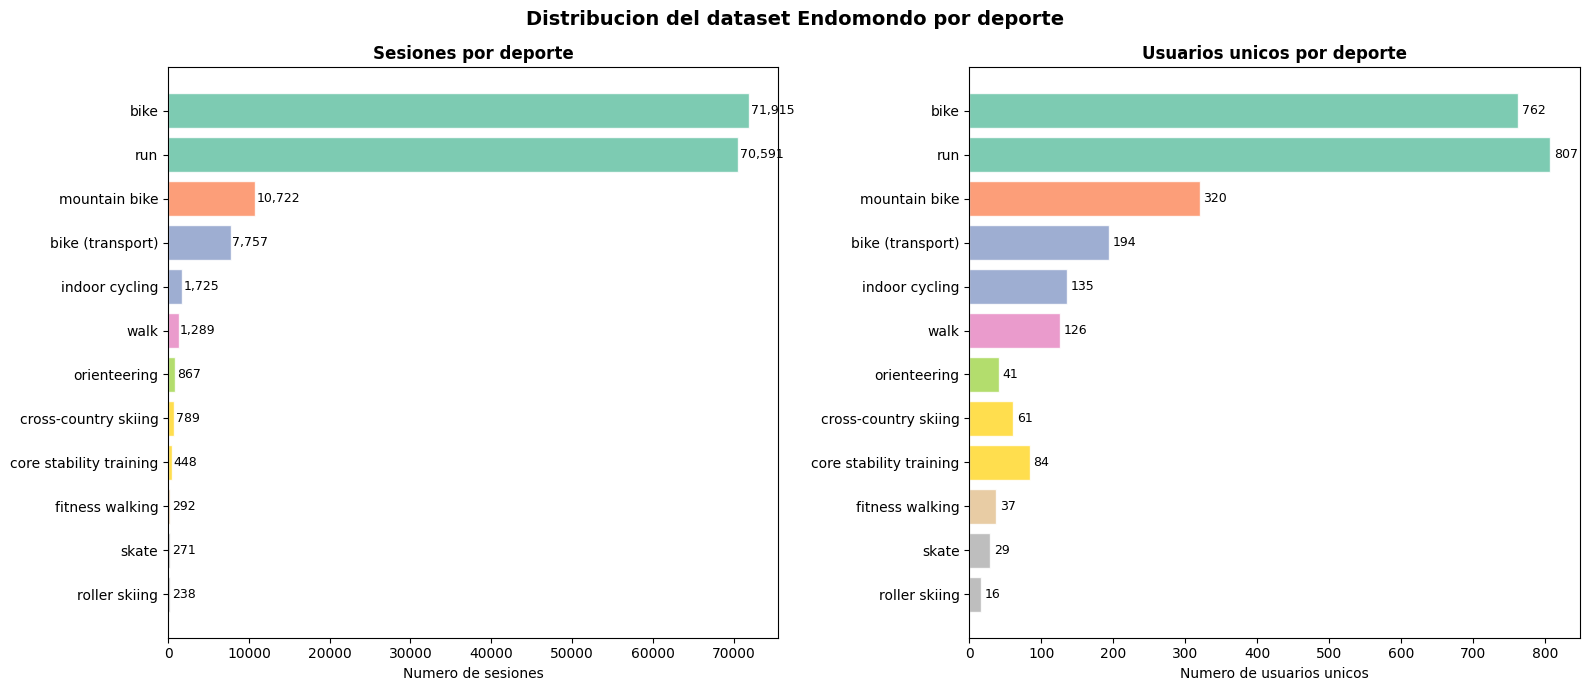

✅ distribucion_deportes.png guardado

💡 Deportes con >100 usuarios — candidatos para ampliar el analisis:
   · bike                      71,915 sesiones |  762 usuarios |  94.4 ses/usuario
   · run                       70,591 sesiones |  807 usuarios |  87.5 ses/usuario
   · mountain bike             10,722 sesiones |  320 usuarios |  33.5 ses/usuario
   · bike (transport)           7,757 sesiones |  194 usuarios |  40.0 ses/usuario
   · indoor cycling             1,725 sesiones |  135 usuarios |  12.8 ses/usuario
   · walk                       1,289 sesiones |  126 usuarios |  10.2 ses/usuario


In [3]:
# BLOQUE 0 — Analisis de distribucion de deportes en el dataset completo
print("Analizando distribucion de deportes en el dataset completo...")
print("(puede tardar unos segundos)\n")

sport_stats = defaultdict(lambda: {"sesiones": 0, "usuarios": set()})

with open(DATA_PATH, "r", encoding="utf-8") as f:
    for line in f:
        try:
            workout = ast.literal_eval(line.strip())
            sport   = workout.get("sport", "desconocido").lower().strip()
            user    = workout.get("userId")
            sport_stats[sport]["sesiones"] += 1
            sport_stats[sport]["usuarios"].add(user)
        except Exception:
            continue

# ── Construir DataFrame de resultados ─────────────────────────────────────
df_sports = (
    pd.DataFrame.from_records([
        {
            "deporte":          sport,
            "n_sesiones":       s["sesiones"],
            "n_usuarios":       len(s["usuarios"]),
            "sesiones_usuario": round(s["sesiones"] / len(s["usuarios"]), 1),
        }
        for sport, s in sport_stats.items()
    ])
    .sort_values("n_sesiones", ascending=False)
    .reset_index(drop=True)
)

# ── Mostrar tabla ──────────────────────────────────────────────────────────
print("=== Distribucion por deporte — Dataset Endomondo completo ===\n")
print(f"{'Deporte':<30} | {'Sesiones':>9} | {'Usuarios':>9} | {'Ses/Usuario':>12}")
print("-" * 68)
for _, row in df_sports.iterrows():
    print(f"  {row['deporte']:<28} | {row['n_sesiones']:>9,} | "
          f"{row['n_usuarios']:>9,} | {row['sesiones_usuario']:>12.1f}")

print(f"\n  TOTAL: {df_sports['n_sesiones'].sum():,} sesiones | "
      f"{df_sports['n_usuarios'].max():,} usuarios unicos")

# ── Visualizacion ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
top_sports = df_sports.head(12)
colors_bar = plt.cm.Set2(np.linspace(0, 1, len(top_sports)))

axes[0].barh(top_sports["deporte"][::-1],
             top_sports["n_sesiones"][::-1],
             color=colors_bar[::-1], edgecolor="white", alpha=0.85)
axes[0].set_xlabel("Numero de sesiones")
axes[0].set_title("Sesiones por deporte", fontsize=12, fontweight="bold")
for i, (_, row) in enumerate(top_sports[::-1].iterrows()):
    axes[0].text(row["n_sesiones"] + 200, i,
                 f"{row['n_sesiones']:,}", va="center", fontsize=9)

axes[1].barh(top_sports["deporte"][::-1],
             top_sports["n_usuarios"][::-1],
             color=colors_bar[::-1], edgecolor="white", alpha=0.85)
axes[1].set_xlabel("Numero de usuarios unicos")
axes[1].set_title("Usuarios unicos por deporte", fontsize=12, fontweight="bold")
for i, (_, row) in enumerate(top_sports[::-1].iterrows()):
    axes[1].text(row["n_usuarios"] + 5, i,
                 f"{row['n_usuarios']:,}", va="center", fontsize=9)

plt.suptitle("Distribucion del dataset Endomondo por deporte",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("distribucion_deportes.png", bbox_inches="tight", dpi=130)
plt.show()
print("✅ distribucion_deportes.png guardado")

# ── Deportes candidatos ───────────────────────────────────────────────────
print("\n💡 Deportes con >100 usuarios — candidatos para ampliar el analisis:")
for _, row in df_sports[df_sports["n_usuarios"] >= 100].iterrows():
    print(f"   · {row['deporte']:<25} "
          f"{row['n_sesiones']:>6,} sesiones | "
          f"{row['n_usuarios']:>4} usuarios | "
          f"{row['sesiones_usuario']:>5.1f} ses/usuario")

In [4]:
# BLOQUE 0 — Extraccion de las sesiones de Run del dataset y sus features

DATA_PATH = Path("data/endomondoHR_proper.json")
OUT_CSV   = Path("data/run_features.csv")
DEPORTE   = "run"

R_TIERRA_KM = 6371.0088  # radio medio terrestre (km)

def haversine_km(lat, lon):
    """Distancia total recorrida (km) sumando tramos consecutivos.
    lat, lon: arrays en grados. Vectorizado con numpy."""
    lat = np.radians(np.asarray(lat, dtype=float))
    lon = np.radians(np.asarray(lon, dtype=float))
    dlat = np.diff(lat)
    dlon = np.diff(lon)
    a = np.sin(dlat / 2)**2 + np.cos(lat[:-1]) * np.cos(lat[1:]) * np.sin(dlon / 2)**2
    tramos = 2 * R_TIERRA_KM * np.arcsin(np.sqrt(np.clip(a, 0, 1)))
    return np.nansum(tramos)

def extraer_features(w):
    """Recibe un dict de sesion y devuelve un dict de caracteristicas agregadas,
    o None si la sesion es inservible (sin tiempo o sin GPS)."""
    ts  = np.asarray(w.get("timestamp", []), dtype=float)
    lat = np.asarray(w.get("latitude", []),  dtype=float)
    lon = np.asarray(w.get("longitude", []), dtype=float)
    alt = np.asarray(w.get("altitude", []),  dtype=float)
    hr  = np.asarray(w.get("heart_rate", []), dtype=float)
    spd = np.asarray(w.get("speed", []),     dtype=float)

    n = len(ts)
    if n < 2 or len(lat) < 2:
        return None

    # Duracion (s y min) a partir de timestamps
    dur_s = ts[-1] - ts[0]
    if dur_s <= 0:
        return None
    dur_min = dur_s / 60.0

    # Distancia por Haversine (km)
    dist_km = haversine_km(lat, lon)

    # Velocidad/ritmo derivados del GPS (robusto) 
    speed_gps_kmh = dist_km / (dur_s / 3600.0) if dur_s > 0 else np.nan
    pace_min_km   = (60.0 / speed_gps_kmh) if speed_gps_kmh > 0 else np.nan

    # Estadisticos del campo 'speed' (para validar unidades en el EDA)
    spd_val = spd[(spd > 0) & (spd < 60)]   # ventana laxa, sin decidir unidad
    spd_mean = np.mean(spd_val) if spd_val.size else np.nan
    spd_max  = np.max(spd_val)  if spd_val.size else np.nan
    spd_std  = np.std(spd_val)  if spd_val.size else np.nan

    # Frecuencia cardiaca (FC valida: 30–230 lpm)
    hr_val = hr[(hr > 30) & (hr < 230)]
    hr_mean = np.mean(hr_val) if hr_val.size else np.nan
    hr_max  = np.max(hr_val)  if hr_val.size else np.nan
    hr_min  = np.min(hr_val)  if hr_val.size else np.nan
    hr_std  = np.std(hr_val)  if hr_val.size else np.nan
    hr_frac_valid = hr_val.size / n

    # Altimetria: desnivel positivo / negativo acumulado
    if len(alt) >= 2:
        dalt = np.diff(alt)
        elev_gain = np.nansum(dalt[dalt > 0])
        elev_loss = -np.nansum(dalt[dalt < 0])
        alt_std   = np.nanstd(alt)
    else:
        elev_gain = elev_loss = alt_std = np.nan

    return {
        "session_id":      w.get("id"),
        "user_id":         w.get("userId"),
        "gender":          w.get("gender"),
        "start_ts":        int(ts[0]),
        "n_points":        n,
        "duration_min":    round(dur_min, 3),
        "distance_km":     round(dist_km, 4),
        "speed_gps_kmh":   round(speed_gps_kmh, 4),
        "pace_min_km":     round(pace_min_km, 4),
        "speed_field_mean": round(spd_mean, 4) if spd_val.size else np.nan,
        "speed_field_max":  round(spd_max, 4)  if spd_val.size else np.nan,
        "speed_field_std":  round(spd_std, 4)  if spd_val.size else np.nan,
        "hr_mean":         round(hr_mean, 2) if hr_val.size else np.nan,
        "hr_max":          round(hr_max, 2)  if hr_val.size else np.nan,
        "hr_min":          round(hr_min, 2)  if hr_val.size else np.nan,
        "hr_std":          round(hr_std, 2)  if hr_val.size else np.nan,
        "hr_frac_valid":   round(hr_frac_valid, 3),
        "elev_gain_m":     round(elev_gain, 1) if not np.isnan(elev_gain) else np.nan,
        "elev_loss_m":     round(elev_loss, 1) if not np.isnan(elev_loss) else np.nan,
        "alt_std_m":       round(alt_std, 2)   if not np.isnan(alt_std) else np.nan,
    }

# Pase principal en streaming
print(f"Extrayendo sesiones de '{DEPORTE}' (esto tarda unos minutos)...\n")
t0 = time.time()

filas = []
n_total = n_run = n_descartadas = 0

with open(DATA_PATH, "r", encoding="utf-8") as f:
    for line in f:
        n_total += 1
        try:
            w = ast.literal_eval(line.strip())
        except Exception:
            continue
        if str(w.get("sport", "")).lower().strip() != DEPORTE:
            continue
        n_run += 1
        fila = extraer_features(w)
        if fila is None:
            n_descartadas += 1
            continue
        filas.append(fila)

        if n_run % 10000 == 0:
            print(f"  {n_run:,} sesiones run procesadas... "
                  f"({time.time()-t0:.0f}s)")

df = pd.DataFrame(filas)
df.to_csv(OUT_CSV, index=False)

print(f"\n✅ Extraccion completada en {time.time()-t0:.0f}s")
print(f"   Lineas totales leidas : {n_total:,}")
print(f"   Sesiones 'run'        : {n_run:,}")
print(f"   Descartadas (sin tiempo/GPS): {n_descartadas:,}")
print(f"   Filas en el CSV       : {len(df):,}")
print(f"   Guardado en           : {OUT_CSV}")
print(f"\n── Vista rapida ──")
print(df.head())
print(f"\n── Tipos y nulos ──")
print(df.info())

Extrayendo sesiones de 'run' (esto tarda unos minutos)...

  10,000 sesiones run procesadas... (127s)
  20,000 sesiones run procesadas... (251s)
  30,000 sesiones run procesadas... (389s)
  40,000 sesiones run procesadas... (602s)
  50,000 sesiones run procesadas... (764s)
  60,000 sesiones run procesadas... (889s)
  70,000 sesiones run procesadas... (1031s)

✅ Extraccion completada en 1037s
   Lineas totales leidas : 167,783
   Sesiones 'run'        : 70,591
   Descartadas (sin tiempo/GPS): 0
   Filas en el CSV       : 70,591
   Guardado en           : data\run_features.csv

── Vista rapida ──
   session_id  user_id gender    start_ts  n_points  duration_min  \
0   321063199  4969375   male  1397079203       500        64.800   
1   303565793  4969375   male  1393908533       500        70.067   
2   302666522  4969375   male  1393687929       500       168.767   
3   296982347  4969375   male  1392480163       500       108.383   
4   295890426  4969375   male  1392180426       500  

Dimensiones: 70,591 sesiones × 20 variables

── Nulos por columna ──
session_id              0
user_id                 0
gender                  0
start_ts                0
n_points                0
duration_min            0
distance_km             0
speed_gps_kmh           0
pace_min_km            14
speed_field_mean    59059
speed_field_max     59059
speed_field_std     59059
hr_mean               107
hr_max                107
hr_min                107
hr_std                107
hr_frac_valid           0
elev_gain_m             0
elev_loss_m             0
alt_std_m               0

── Estadisticos descriptivos ──
                      count              mean             std               min               25%               50%               75%               max
session_id       70,591.000   371,732,014.149 151,028,853.324     1,704,139.000   271,469,353.000   361,165,734.000   480,850,128.000   665,294,454.000
user_id          70,591.000     4,466,210.429   3,822,439.886            6

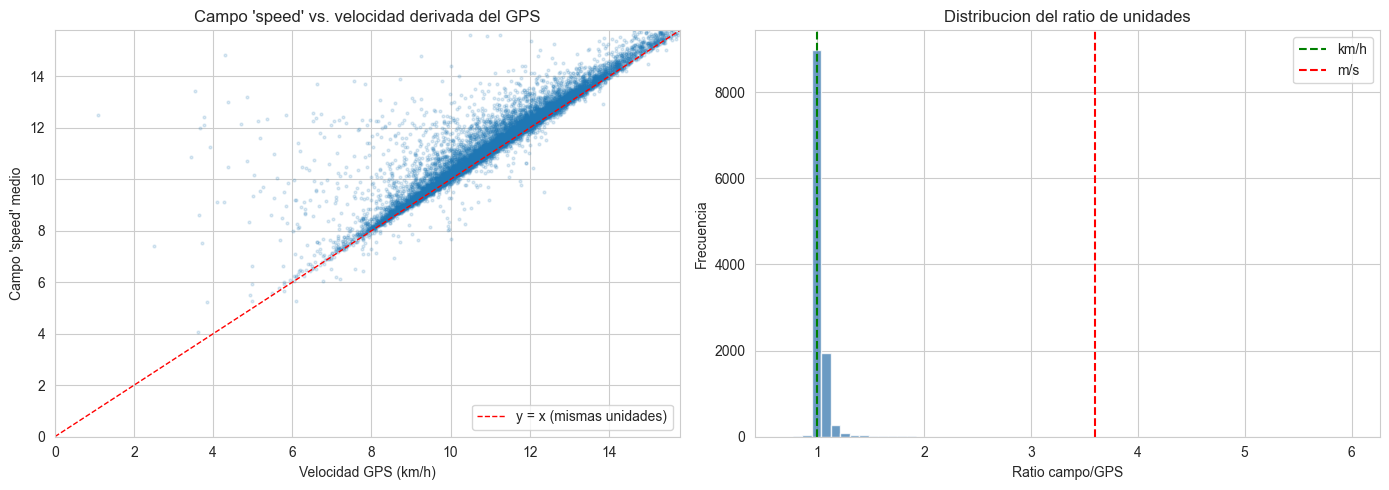

In [5]:
# BLOQUE 3 — EDA, diagnostivo y validacion de unidades

sns.set_style("whitegrid")
OUT_CSV = Path("data/run_features.csv")

df = pd.read_csv(OUT_CSV)

print(f"Dimensiones: {df.shape[0]:,} sesiones × {df.shape[1]} variables\n")

print("── Nulos por columna ──")
print(df.isna().sum().to_string())

print("\n── Estadisticos descriptivos ──")
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
print(df.describe().T.to_string())

# Sesiones por usuario (relevante: perfilamos corredores)
ses_por_user = df.groupby("user_id").size()
print(f"\n── Sesiones por usuario ──")
print(f"  Usuarios unicos : {df['user_id'].nunique():,}")
print(f"  Media / mediana : {ses_por_user.mean():.1f} / {ses_por_user.median():.0f}")
print(f"  Min / max       : {ses_por_user.min()} / {ses_por_user.max()}")

m = (df["speed_field_mean"].notna() & df["speed_gps_kmh"].notna()
     & (df["speed_gps_kmh"] > 0))
ratio = df.loc[m, "speed_field_mean"] / df.loc[m, "speed_gps_kmh"]
print(f"\n── Validacion de unidades (speed_field_mean / speed_gps_kmh) ──")
print(f"  Mediana del ratio : {ratio.median():.3f}")
print(f"  Interpretacion    : ≈1 → campo en km/h | ≈3.6 → campo en m/s")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].scatter(df.loc[m, "speed_gps_kmh"], df.loc[m, "speed_field_mean"],
              s=4, alpha=0.15)
lim = np.nanpercentile(df.loc[m, "speed_gps_kmh"], 99)
ax[0].plot([0, lim], [0, lim], "r--", lw=1, label="y = x (mismas unidades)")
ax[0].set(xlim=(0, lim), ylim=(0, lim),
          xlabel="Velocidad GPS (km/h)", ylabel="Campo 'speed' medio",
          title="Campo 'speed' vs. velocidad derivada del GPS")
ax[0].legend()

ratio.clip(0, 6).hist(bins=60, ax=ax[1], color="steelblue", alpha=0.8)
ax[1].axvline(1.0, color="green", ls="--", label="km/h")
ax[1].axvline(3.6, color="red",   ls="--", label="m/s")
ax[1].set(xlabel="Ratio campo/GPS", ylabel="Frecuencia",
          title="Distribucion del ratio de unidades")
ax[1].legend()
plt.tight_layout()
plt.show()

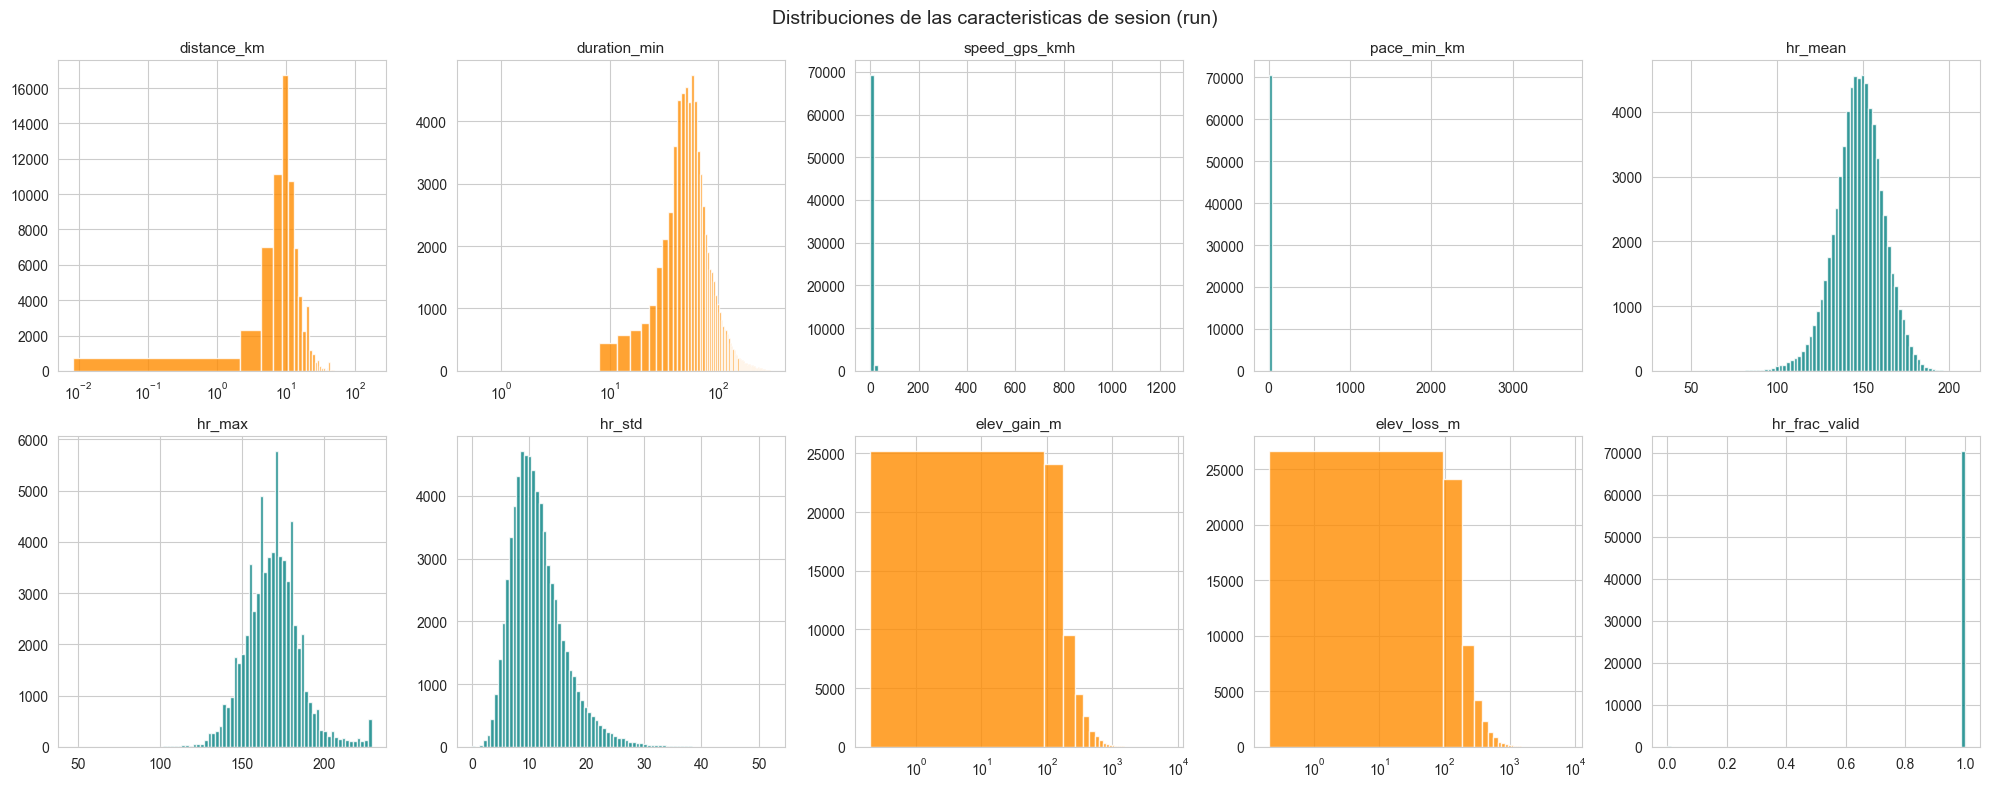

── Cobertura de frecuencia cardiaca ──
  Sesiones con hr_mean valida : 70,484 (99.8%)
  hr_frac_valid (mediana)     : 1.000


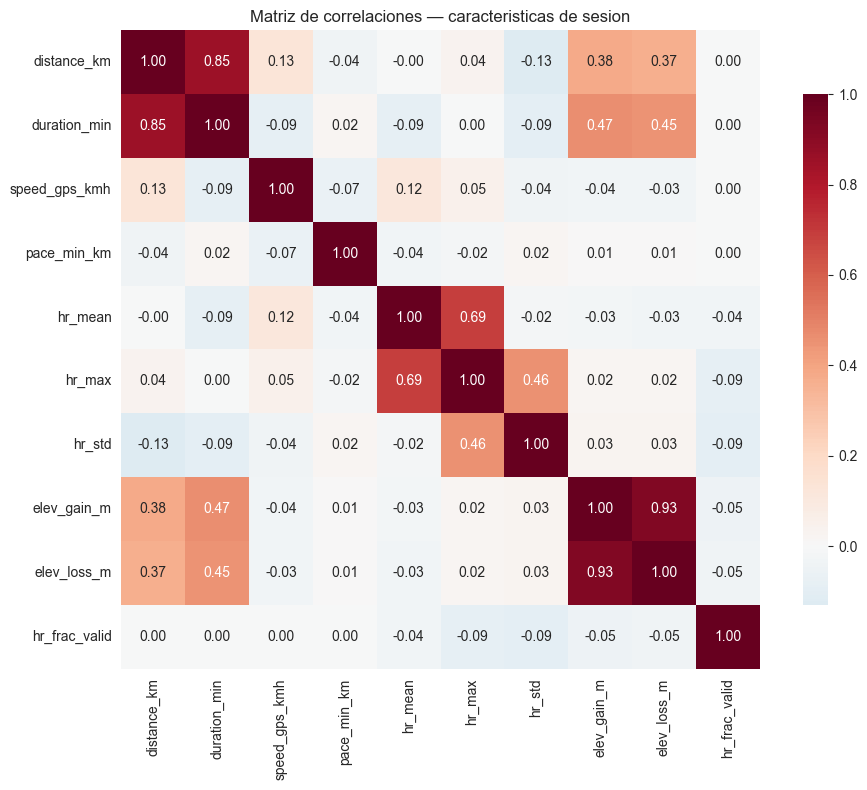

In [6]:
# BLOQUE 3 — EDA, correlaciones 

# Variables continuas de interes (excluimos IDs y timestamps)
cont = ["distance_km", "duration_min", "speed_gps_kmh", "pace_min_km",
        "hr_mean", "hr_max", "hr_std", "elev_gain_m", "elev_loss_m",
        "hr_frac_valid"]
cont = [c for c in cont if c in df.columns]

# Histogramas
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, col in zip(axes.ravel(), cont):
    serie = df[col].dropna()
    # escala log en el eje X para variables muy sesgadas a la derecha
    if col in ("distance_km", "duration_min", "elev_gain_m", "elev_loss_m"):
        serie = serie[serie > 0]
        ax.hist(serie, bins=80, color="darkorange", alpha=0.8)
        ax.set_xscale("log")
    else:
        ax.hist(serie, bins=80, color="teal", alpha=0.8)
    ax.set_title(col, fontsize=11)
for ax in axes.ravel()[len(cont):]:
    ax.axis("off")
fig.suptitle("Distribuciones de las caracteristicas de sesion (run)", fontsize=14)
plt.tight_layout()
plt.show()

# Calidad de la FC: ¿cuantas sesiones tienen FC usable?
print("── Cobertura de frecuencia cardiaca ──")
print(f"  Sesiones con hr_mean valida : "
      f"{df['hr_mean'].notna().sum():,} ({df['hr_mean'].notna().mean()*100:.1f}%)")
print(f"  hr_frac_valid (mediana)     : {df['hr_frac_valid'].median():.3f}")

# Matriz de correlaciones (Pearson)
corr = df[cont].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, cbar_kws={"shrink": .8})
plt.title("Matriz de correlaciones — caracteristicas de sesion")
plt.tight_layout()
plt.show()

In [32]:
# BLOQUE 3 — limpieza outliers, variables correlacionadas y filtros fisioloicos

df = pd.read_csv("data/run_features.csv")
n0 = len(df)
print(f"Partimos de {n0:,} sesiones\n")

# Eliminar columnas redundantes
df = df.drop(columns=["speed_field_mean", "speed_field_max",
                      "speed_field_std", "n_points"])
# eliminamos las que tienen alta correlacion entre ellas
df.drop(columns=[ "elev_loss_m", "duration_min"], inplace=True)

#Eliminar filas sin FC o sin ritmo validos
antes = len(df)
df = df.dropna(subset=["hr_mean"])
print(f"Nulos (FC/ritmo) eliminados : {antes - len(df):,}")

# Filtros fisiologicos 
filtros = {
    "distance_km":   (0.5, 100),    # entre 500 m y 100 km 
    "speed_gps_kmh": (4,   30),    # trote lento a ritmo de elite
    "hr_mean":       (80,  220),   # FC media sostenible corriendo
    "hr_max":        (80,  220),
    "elev_gain_m":   (0,   2000),  # desnivel positivo por sesion
}
print("\n── Filtros fisiologicos (sesiones eliminadas por cada cota) ──")
for col, (lo, hi) in filtros.items():
    fuera = ((df[col] < lo) | (df[col] > hi)).sum()
    df = df[(df[col] >= lo) & (df[col] <= hi)]
    print(f"  {col:<15} [{lo}, {hi}]  → -{fuera:,}")
print(f"  Subtotal: {len(df):,} sesiones")

def quitar_outliers(df, columna, k=3.0):
    q1 = df[columna].quantile(0.25)
    q3 = df[columna].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - k * iqr
    limite_superior = q3 + k * iqr
    return df[(df[columna] >= limite_inferior) & (df[columna] <= limite_superior)]

print("--- Eliminacion de Outliers ---")
for col in ["distance_km", "elev_gain_m", "hr_std", "speed_gps_kmh", "hr_mean", "hr_max"]:
    df = quitar_outliers(df, col, k=3.0)

print(f"\nFilas totales tras la limpieza: {len(df)}")

#Resumen final
df.to_csv("data/run_clean.csv", index=False)
print(f"\n✅ Limpieza completada")
print(f"   Sesiones: {n0:,} → {len(df):,}  (retenido {len(df)/n0*100:.1f}%)")
print(f"   Usuarios: {df['user_id'].nunique():,}")
print(f"   Guardado en: data/run_clean.csv\n")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
print(df[["distance_km","speed_gps_kmh",
          "hr_mean","hr_max","hr_std","elev_gain_m"]].describe().T.to_string())

Partimos de 70,591 sesiones

Nulos (FC/ritmo) eliminados : 107

── Filtros fisiologicos (sesiones eliminadas por cada cota) ──
  distance_km     [0.5, 100]  → -36
  speed_gps_kmh   [4, 30]  → -450
  hr_mean         [80, 220]  → -18
  hr_max          [80, 220]  → -901
  elev_gain_m     [0, 2000]  → -41
  Subtotal: 69,038 sesiones
--- Eliminacion de Outliers ---

Filas totales tras la limpieza: 65448

✅ Limpieza completada
   Sesiones: 70,591 → 65,448  (retenido 92.7%)
   Usuarios: 791
   Guardado en: data/run_clean.csv

                  count   mean    std   min    25%    50%    75%    max
distance_km   65,448.00  11.31   5.15  0.73   7.99  10.20  13.67  32.95
speed_gps_kmh 65,448.00  10.70   1.92  4.00   9.48  10.75  11.93  19.26
hr_mean       65,448.00 147.41  13.81 86.62 138.95 147.76 156.55 202.23
hr_max        65,448.00 168.06  15.42 99.00 158.00 168.00 178.00 220.00
hr_std        65,448.00  11.28   4.39  0.00   8.17  10.60  13.64  30.21
elev_gain_m   65,448.00 143.82 108.59  0.00

In [33]:
# BLOQUE 4 - Agregacion por corredor

df = pd.read_csv("data/run_clean.csv")
MIN_SESIONES = 3   # umbral de inclusion para perfiles estables

conteo  = df.groupby("user_id").size()
validos = conteo[conteo >= MIN_SESIONES].index
n_antes = df["user_id"].nunique()
df = df[df["user_id"].isin(validos)].copy()
print(f"Corredores: {n_antes} → {df['user_id'].nunique()} "
      f"(≥{MIN_SESIONES} sesiones) | sesiones: {len(df):,}")

# Mediana = tendencia central robusta; std = consistencia entre sesiones
perfiles = df.groupby("user_id").agg(
    n_sesiones       = ("session_id",   "size"),
    dist_median      = ("distance_km",  "median"),
    dist_std         = ("distance_km",  "std"),
    speed_median     = ("speed_gps_kmh","median"),
    speed_std        = ("speed_gps_kmh","std"),
    pace_median      = ("pace_min_km",  "median"),
    hr_mean_median   = ("hr_mean",      "median"),
    hr_max_median    = ("hr_max",       "median"),
    hr_std_median    = ("hr_std",       "median"),
    elev_gain_median = ("elev_gain_m",  "median"),
).reset_index()

perfiles.to_csv("data/run_profiles_raw.csv", index=False)
print(f"\n✅ {len(perfiles)} perfiles guardados en data/run_profiles_raw.csv")
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
print(perfiles.drop(columns="user_id").describe().T.to_string())

Corredores: 791 → 716 (≥3 sesiones) | sesiones: 65,340

✅ 716 perfiles guardados en data/run_profiles_raw.csv
                   count    mean     std     min     25%     50%     75%       max
n_sesiones       716.000  91.257 106.650   3.000  18.750  54.000 125.250 1,085.000
dist_median      716.000  10.036   2.715   2.276   8.383  10.013  11.344    22.002
dist_std         716.000   3.961   1.543   0.034   2.857   3.988   5.089     8.595
speed_median     716.000  10.417   1.641   4.631   9.340  10.528  11.491    17.855
speed_std        716.000   1.211   0.521   0.059   0.834   1.140   1.524     3.719
pace_median      716.000   5.921   1.065   3.360   5.222   5.699   6.424    12.957
hr_mean_median   716.000 149.411  10.864 103.830 142.665 149.752 156.650   191.085
hr_max_median    716.000 169.748  10.351 138.000 163.000 170.000 176.625   207.000
hr_std_median    716.000  11.279   2.701   0.000   9.534  11.135  12.620    25.750
elev_gain_median 716.000 130.744  85.336   0.000  74.950 108

Matriz de perfiles: 716 corredores × 8 variables

── Varianza explicada acumulada ──
  PC1:  25.4%
  PC2:  49.3%
  PC3:  64.3%
  PC4:  77.5%
  PC5:  86.7%
  PC6:  94.2%  ← 90%
  PC7:  98.9%
  PC8: 100.0%
Componentes retenidos (≥90% var.): 6

── Metricas por k ──
 k    inercia  silhouette
 2 4,485.2703      0.1623
 3 3,880.8295      0.1566
 4 3,520.0275      0.1664
 5 3,262.4768      0.1489
 6 3,059.0765      0.1397
 7 2,892.9913      0.1373
 8 2,739.3091      0.1429
 9 2,629.3978      0.1289
10 2,538.1409      0.1302
11 2,451.8894      0.1364
12 2,382.0493      0.1391
Codo (a la vista): k=5 | Mejor silueta: k=4

Mejor k → Codo (kneedle): 5 | Silueta (max): 4


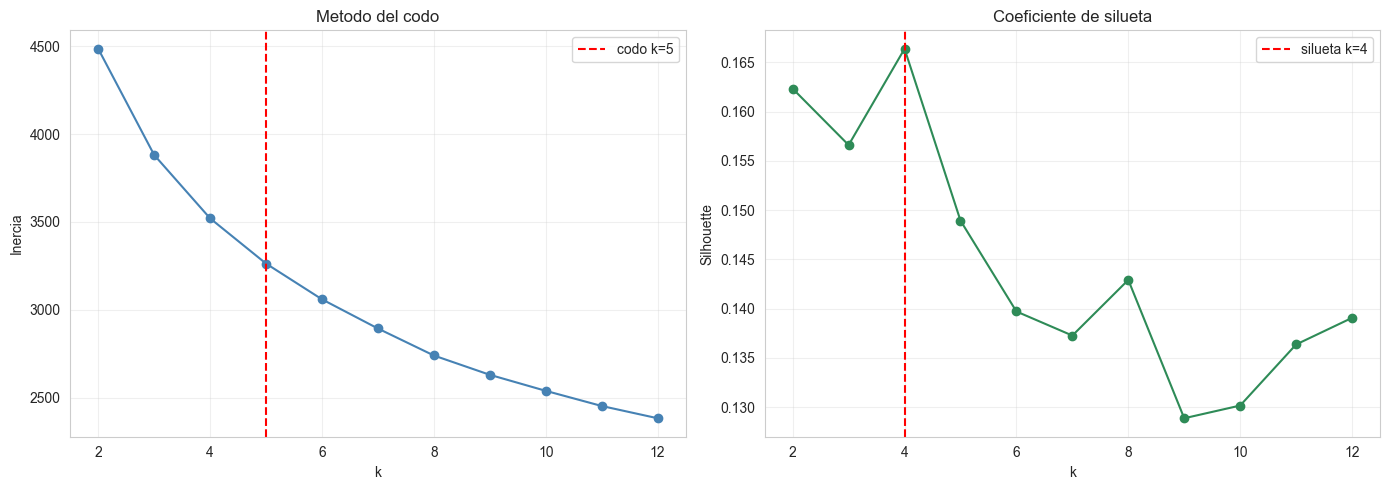

In [34]:
# BLOQUE 5 - Normalicacion, PCA y clustering de perfiles (Codo y silueta)

perfiles = pd.read_csv("data/run_profiles_raw.csv")

FEATURES = ["dist_median", "dist_std", "speed_median",
            "speed_std", "hr_mean_median", "hr_max_median",
            "hr_std_median", "elev_gain_median"]

X = perfiles[FEATURES].fillna(perfiles[FEATURES].median()).values
print(f"Matriz de perfiles: {X.shape[0]} corredores × {X.shape[1]} variables")

scaler = StandardScaler()
Xs = scaler.fit_transform(X)

#PCA: no de componentes por varianza acumulada (≥90%)
pca_full = PCA(random_state=42).fit(Xs)
var_acum = np.cumsum(pca_full.explained_variance_ratio_)
n_comp   = int(np.argmax(var_acum >= 0.90) + 1)

print("\n── Varianza explicada acumulada ──")
for i, acc in enumerate(var_acum, 1):
    marca = "  ← 90%" if i == n_comp else ""
    print(f"  PC{i}: {acc*100:5.1f}%{marca}")
print(f"Componentes retenidos (≥90% var.): {n_comp}")

pca = PCA(n_components=n_comp, random_state=42)
Xp  = pca.fit_transform(Xs)

# Barrido de k: inercia (codo) y silueta
ks         = list(range(2, 13))
inercias   = []
siluetas   = []
for k in ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    etiquetas = km.fit_predict(Xp)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(Xp, etiquetas))

tabla = pd.DataFrame({"k": ks, "inercia": inercias, "silhouette": siluetas})
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
print("\n── Metricas por k ──")
print(tabla.to_string(index=False))

# Miro la grafica del codo y elijo k a la vista
k_codo = 5   # el codo se aprecia hacia k=5
k_sil = int(tabla.loc[tabla["silhouette"].idxmax(), "k"])
print(f"Codo (a la vista): k={k_codo} | Mejor silueta: k={k_sil}")

print(f"\nMejor k → Codo (kneedle): {k_codo} | Silueta (max): {k_sil}")

#Graficos
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(ks, inercias, "o-", color="steelblue")
ax[0].axvline(k_codo, color="red", ls="--", label=f"codo k={k_codo}")
ax[0].set(title="Metodo del codo", xlabel="k", ylabel="Inercia")
ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(ks, siluetas, "o-", color="seagreen")
ax[1].axvline(k_sil, color="red", ls="--", label=f"silueta k={k_sil}")
ax[1].set(title="Coeficiente de silueta", xlabel="k", ylabel="Silhouette")
ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [35]:
# BLOQUE 6 - K-Means (k=5): ajuste + estabilidad

K = 5

km = KMeans(n_clusters=K, n_init=50, random_state=42)
etiquetas = km.fit_predict(Xp)
perfiles["cluster"] = etiquetas

print(f"K-Means final (k={K})")
print(f"  Inercia     : {km.inertia_:,.1f}")
print(f"  Silueta     : {silhouette_score(Xp, etiquetas):.3f}")
print(f"  Iteraciones : {km.n_iter_}")

# Estabilidad ante la semilla: ARI entre 10 reejecuciones
# ARI=1 → particiones identicas; ~0 → coincidencia azarosa.
aris = [adjusted_rand_score(etiquetas,
        KMeans(n_clusters=K, n_init=20, random_state=s).fit_predict(Xp))
        for s in range(1, 11)]
print(f"  Estabilidad (ARI, 10 semillas): media={np.mean(aris):.3f}  "
      f"min={np.min(aris):.3f}")

K-Means final (k=5)
  Inercia     : 3,262.4
  Silueta     : 0.149
  Iteraciones : 25
  Estabilidad (ARI, 10 semillas): media=0.834  min=0.773


In [36]:
# BLOQUE 7 - Analisis de los clusters
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Tamanos
tam = perfiles["cluster"].value_counts().sort_index()
print("── Tamano de cada cluster ──")
for c, n in tam.items():
    print(f"  Cluster {c}: {n:>3} corredores ({n/len(perfiles)*100:.1f}%)")

#Perfil mediano por cluster en unidades originales
resumen = perfiles.groupby("cluster")[FEATURES].median().round(2)
print("\n── Perfil mediano por cluster (unidades originales) ──")
print(resumen.to_string())

#Desviacion de cada cluster respecto a la mediana global (z-score)
glob = perfiles[FEATURES].median()
zsc = ((resumen - glob) / perfiles[FEATURES].std()).round(2)
print("\n── Perfil estandarizado (z-score sobre la mediana global) ──")
print(zsc.to_string())

# guardamos el resumen para los graficos siguientes
resumen.to_csv("data/cluster_resumen.csv")
zsc.to_csv("data/cluster_zscore.csv")

── Tamano de cada cluster ──
  Cluster 0: 133 corredores (18.6%)
  Cluster 1: 134 corredores (18.7%)
  Cluster 2: 206 corredores (28.8%)
  Cluster 3: 179 corredores (25.0%)
  Cluster 4:  64 corredores (8.9%)

── Perfil mediano por cluster (unidades originales) ──
         dist_median  dist_std  speed_median  speed_std  hr_mean_median  hr_max_median  hr_std_median  elev_gain_median
cluster                                                                                                                
0               7.31      2.45          9.06       0.91          144.06         165.00          11.54             76.90
1              10.09      4.93         11.45       1.77          145.10         167.00          11.29            123.15
2               9.86      3.80         10.61       1.16          158.69         178.50          11.88             97.00
3              11.18      4.78         10.71       1.02          146.20         164.00           9.33            105.30
4              1

C:\Users\peare\AppData\Local\Temp\ipykernel_16900\867715161.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


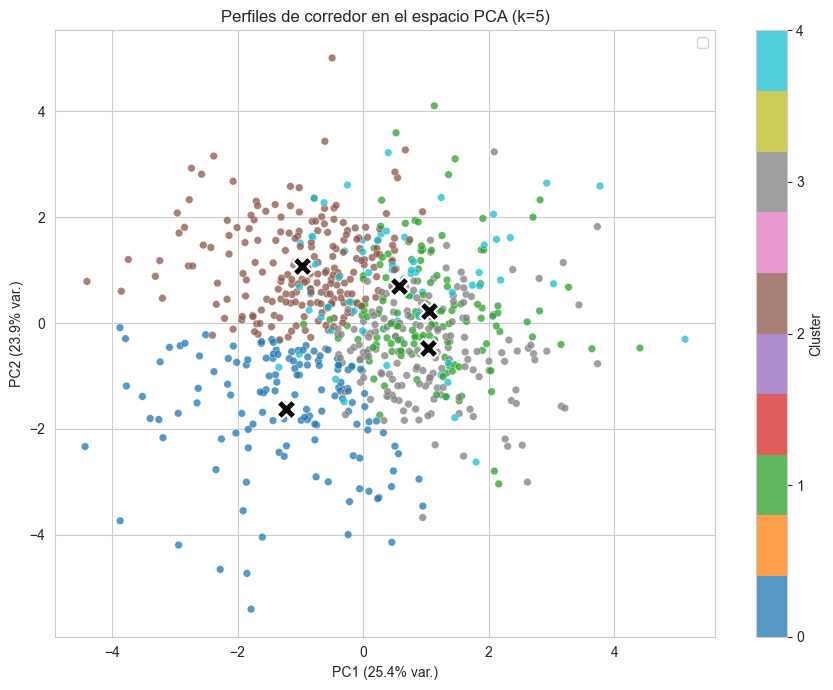

✅ fig_clusters_pca.png guardado


In [37]:
# BLOQUE 8 - Visualizacion de los clusters

var = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(Xp[:, 0], Xp[:, 1], c=perfiles["cluster"], cmap="tab10",
                s=30, alpha=0.75, edgecolor="white", linewidth=0.3)
cen = km.cluster_centers_
# centroide de cada grupo (media de sus puntos en el espacio PCA)
for c in np.unique(perfiles["cluster"]):
    cx, cy = Xp[perfiles["cluster"] == c, 0].mean(), Xp[perfiles["cluster"] == c, 1].mean()
    ax.scatter(cx, cy, c="black", marker="X", s=200,
               edgecolor="white", linewidth=1.5, zorder=5)
ax.set_xlabel(f"PC1 ({var[0]:.1f}% var.)")
ax.set_ylabel(f"PC2 ({var[1]:.1f}% var.)")
ax.set_title("Perfiles de corredor en el espacio PCA (k=5)")
ax.legend()
plt.colorbar(sc, ax=ax, label="Cluster", ticks=range(5))
plt.tight_layout()
plt.savefig("fig_clusters_pca.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ fig_clusters_pca.png guardado")

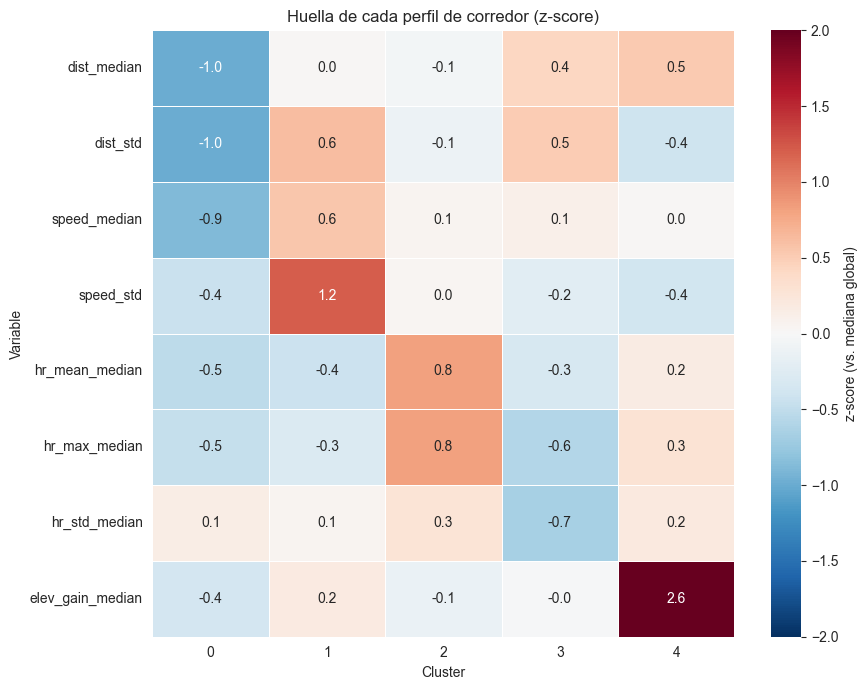

✅ fig_clusters_heatmap.png guardado


In [38]:
# BLOQUE 9 - Heatmap de los clusters

zsc = pd.read_csv("data/cluster_zscore.csv", index_col=0)

plt.figure(figsize=(9, 7))
sns.heatmap(zsc.T, cmap="RdBu_r", center=0, vmin=-2, vmax=2,
            annot=True, fmt=".1f", linewidths=0.5,
            cbar_kws={"label": "z-score (vs. mediana global)"})
plt.xlabel("Cluster")
plt.ylabel("Variable")
plt.title("Huella de cada perfil de corredor (z-score)")
plt.tight_layout()
plt.savefig("fig_clusters_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ fig_clusters_heatmap.png guardado")

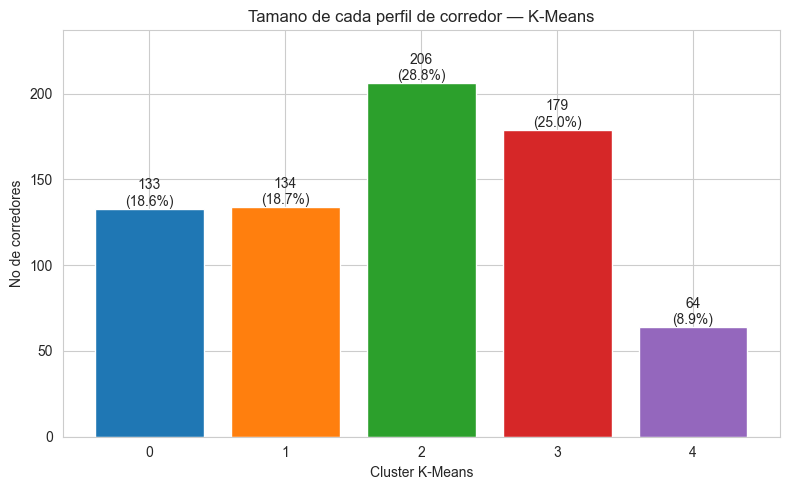

✅ fig_kmeans_tamanos.png guardado


In [39]:
# BLOQUE 10 - Distribucion de los usuarios por cluster

tam = perfiles["cluster"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.bar(tam.index.astype(str), tam.values,
                color=plt.cm.tab10(range(len(tam))), edgecolor="white")
for b, n in zip(barras, tam.values):
    ax.text(b.get_x() + b.get_width()/2, b.get_height(),
            f"{n}\n({n/tam.sum()*100:.1f}%)",
            ha="center", va="bottom", fontsize=10)
ax.set_xlabel("Cluster K-Means"); ax.set_ylabel("No de corredores")
ax.set_title("Tamano de cada perfil de corredor — K-Means")
ax.margins(y=0.15)
plt.tight_layout()
plt.savefig("fig_kmeans_tamanos.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ fig_kmeans_tamanos.png guardado")

Dimensiones (PCA): 6  →  min_samples = 12
eps sugerido por el codo: 2.224


C:\Users\peare\AppData\Local\Temp\ipykernel_16900\2816477677.py:16: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  d = np.abs(np.cross(p2 - p1, np.c_[xn, yn] - p1)) / np.linalg.norm(p2 - p1)


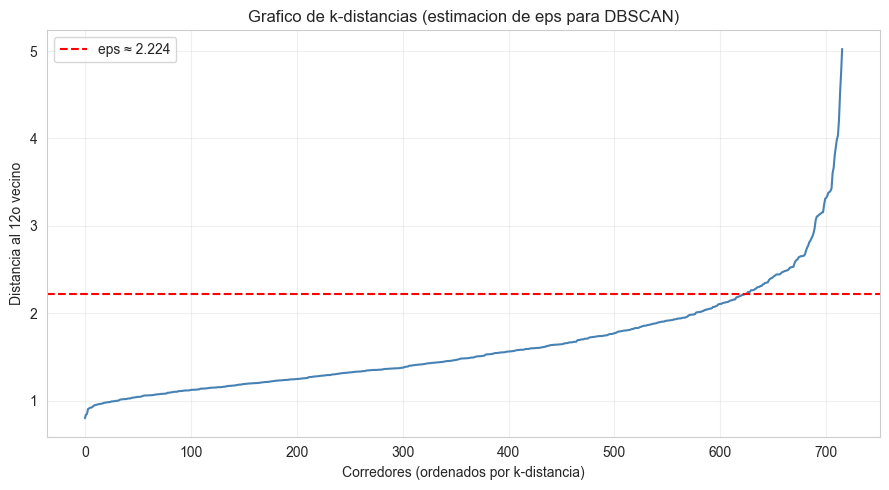

In [40]:
# BLOQUE 10 - Estimacion de eps para DBSCAN

min_samples = 2 * Xp.shape[1]
print(f"Dimensiones (PCA): {Xp.shape[1]}  →  min_samples = {min_samples}")

# Distancia de cada punto a su k-esimo vecino mas cercano (k = min_samples)
nn = NearestNeighbors(n_neighbors=min_samples).fit(Xp)
dist, _ = nn.kneighbors(Xp)
kdist = np.sort(dist[:, -1])          # k-esima distancia, ordenada ascendente

# ── Codo automatico: maxima distancia a la recta extremo-extremo ───────────
x = np.arange(len(kdist), dtype=float)
xn = (x - x.min()) / (x.max() - x.min())
yn = (kdist - kdist.min()) / (kdist.max() - kdist.min())
p1, p2 = np.array([xn[0], yn[0]]), np.array([xn[-1], yn[-1]])
d = np.abs(np.cross(p2 - p1, np.c_[xn, yn] - p1)) / np.linalg.norm(p2 - p1)
eps_codo = float(kdist[np.argmax(d)])
print(f"eps sugerido por el codo: {eps_codo:.3f}")

# ── Grafico ─────────────────────────────────────────────────────────────────
plt.figure(figsize=(9, 5))
plt.plot(kdist, color="steelblue")
plt.axhline(eps_codo, color="red", ls="--", label=f"eps ≈ {eps_codo:.3f}")
plt.xlabel("Corredores (ordenados por k-distancia)")
plt.ylabel(f"Distancia al {min_samples}o vecino")
plt.title("Grafico de k-distancias (estimacion de eps para DBSCAN)")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fig_dbscan_kdist.png", dpi=150, bbox_inches="tight")
plt.show()

In [41]:
# BLOQUE 11 - Barrido de eps y min_samples para DBSCAN

# Rejilla de eps centrada en el codo; min_samples alrededor de la heuristica
eps_grid = np.round(np.linspace(eps_codo * 0.6, eps_codo * 1.6, 9), 3)
ms_grid  = [Xp.shape[1], int(1.5*Xp.shape[1]), 2*Xp.shape[1], 3*Xp.shape[1]]

filas = []
for eps in eps_grid:
    for ms in ms_grid:
        etq = DBSCAN(eps=eps, min_samples=ms).fit_predict(Xp)
        n_clusters = len(set(etq)) - (1 if -1 in etq else 0)
        n_ruido    = int((etq == -1).sum())
        pct_ruido  = n_ruido / len(etq) * 100
        # Silueta solo si hay ≥2 clusteres y suficientes puntos no-ruido
        mask = etq != -1
        if n_clusters >= 2 and mask.sum() > n_clusters:
            sil = silhouette_score(Xp[mask], etq[mask])
        else:
            sil = np.nan
        filas.append({"eps": eps, "min_samples": ms, "n_clusters": n_clusters,
                      "pct_ruido": round(pct_ruido, 1),
                      "silhouette": round(sil, 3) if not np.isnan(sil) else np.nan})

tabla = pd.DataFrame(filas)
print("── Barrido DBSCAN ──")
print(tabla.to_string(index=False))

# Candidatos: 2–8 clusteres y ruido < 30% (evita soluciones degeneradas)
cand = tabla[(tabla["n_clusters"].between(2, 8)) & (tabla["pct_ruido"] < 30)]
print("\n── Combinaciones razonables (2–8 clusteres, ruido <30%) ──")
print(cand.sort_values("silhouette", ascending=False).to_string(index=False)
      if not cand.empty
      else "  (ninguna combinacion cumple el criterio)")

── Barrido DBSCAN ──
 eps  min_samples  n_clusters  pct_ruido  silhouette
1.33            6           2      30.20        0.24
1.33            9           1      34.80         NaN
1.33           12           1      38.30         NaN
1.33           18           1      43.70         NaN
1.61            6           1      13.80         NaN
1.61            9           1      16.30         NaN
1.61           12           1      18.90         NaN
1.61           18           1      23.20         NaN
1.89            6           1       6.00         NaN
1.89            9           1       6.70         NaN
1.89           12           1       8.10         NaN
1.89           18           1      10.10         NaN
2.17            6           1       3.60         NaN
2.17            9           1       3.80         NaN
2.17           12           1       4.30         NaN
2.17           18           1       5.00         NaN
2.45            6           1       1.70         NaN
2.45            9        

In [42]:
# BLOQUE 12 - Creacion DBSCAN optimo

EPS = round(float(eps_codo), 3)   # codo del grafico de k-distancias (Bloque 11)
MS  = 2 * Xp.shape[1]             # heuristica 2×dim (Schubert et al., 2017)
print(f"DBSCAN optimo  →  eps = {EPS} | min_samples = {MS}")

db = DBSCAN(eps=EPS, min_samples=MS)
etq_db = db.fit_predict(Xp)
perfiles["cluster_dbscan"] = etq_db

print("✅ Modelo ajustado (etiquetas en perfiles['cluster_dbscan'])")

DBSCAN optimo  →  eps = 2.224 | min_samples = 12
✅ Modelo ajustado (etiquetas en perfiles['cluster_dbscan'])


In [43]:
# BLOQUE 13 - Barrido de eps y min_samples para DBSCAN

#Recuento de clusteres, ruido y tipos de punto
n_clusters = len(set(etq_db)) - (1 if -1 in etq_db else 0)
n_ruido    = int((etq_db == -1).sum())
n_nucleo   = len(db.core_sample_indices_)
print("── Resultado del modelo ──")
print(f"  Clusteres encontrados : {n_clusters}")
print(f"  Puntos de ruido       : {n_ruido} ({n_ruido/len(etq_db)*100:.1f}%)")
print(f"  Puntos nucleo         : {n_nucleo}")
print(f"  Puntos frontera       : {len(etq_db)-n_ruido-n_nucleo}")

#Silueta (solo si hay ≥2 clusteres)
if n_clusters >= 2:
    m = etq_db != -1
    print(f"  Silueta (sin ruido)   : {silhouette_score(Xp[m], etq_db[m]):.3f}")
else:
    print("  Silueta               : no definida (un solo cluster)")
    print("  → El modelo optimo NO segmenta el espacio: confirma el continuo.")

#Perfil ruido vs. cluster
FEATURES_INT = ["dist_median", "speed_median", "hr_mean_median",
                "elev_gain_median", "dist_std"]
perfiles["tipo"] = ["ruido" if e == -1 else "cluster" for e in etq_db]
print("\n── Perfil mediano: ruido vs. cluster (unidades originales) ──")
print(perfiles.groupby("tipo")[FEATURES_INT].median().round(2))

── Resultado del modelo ──
  Clusteres encontrados : 1
  Puntos de ruido       : 28 (3.9%)
  Puntos nucleo         : 625
  Puntos frontera       : 63
  Silueta               : no definida (un solo cluster)
  → El modelo optimo NO segmenta el espacio: confirma el continuo.

── Perfil mediano: ruido vs. cluster (unidades originales) ──
         dist_median  speed_median  hr_mean_median  elev_gain_median  dist_std
tipo                                                                          
cluster        10.01         10.53          149.93            107.55      4.02
ruido           9.52          9.40          135.82            133.45      2.84


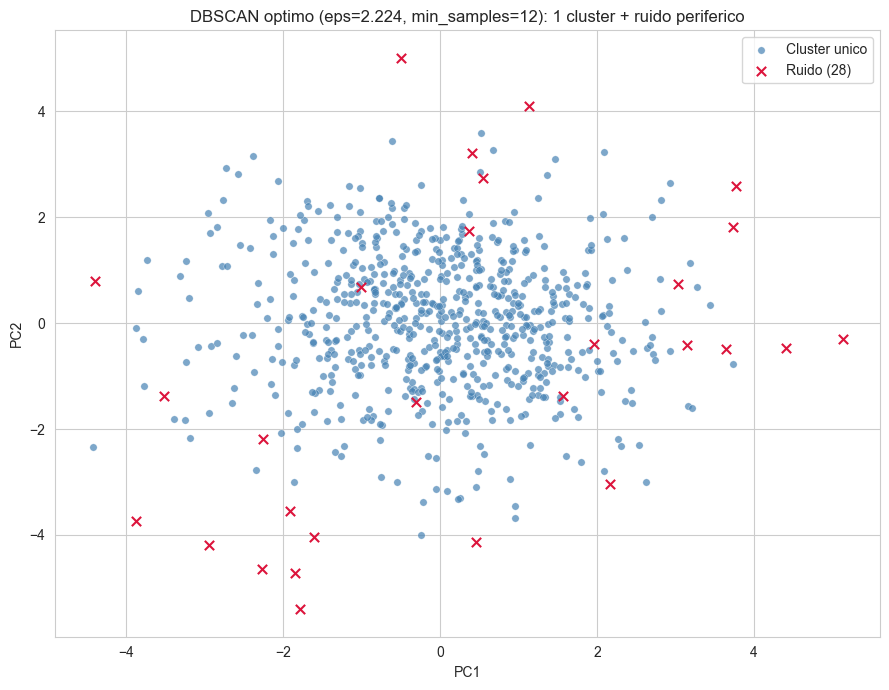

✅ fig_dbscan_modelo.png guardado


In [44]:
# BLOQUE 14 - Visualizacion del DBSCAN optimo

n_ruido = int((etq_db == -1).sum())
m = etq_db != -1

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(Xp[m, 0], Xp[m, 1], c="steelblue", s=28, alpha=0.7,
           edgecolor="white", linewidth=0.3, label="Cluster unico")
ax.scatter(Xp[~m, 0], Xp[~m, 1], c="crimson", s=45, marker="x",
           linewidth=1.5, label=f"Ruido ({n_ruido})")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title(f"DBSCAN optimo (eps={round(float(eps_codo),3)}, "
             f"min_samples={2*Xp.shape[1]}): 1 cluster + ruido periferico")
ax.legend()
plt.tight_layout()
plt.savefig("fig_dbscan_modelo.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ fig_dbscan_modelo.png guardado")

In [45]:
# BLOQUE 15 - Analisis jerarquico (dendrograma y sugerencias de K)
Z = linkage(Xp, method="ward")

distancias = Z[:, 2]
print("--- Saltos de distancia en el dendrograma ---")
for k in range(2, 8):
    salto = distancias[-(k-1)] - distancias[-k]
    print(f"  k={k}: salto = {salto:.2f}")

--- Saltos de distancia en el dendrograma ---
  k=2: salto = 9.07
  k=3: salto = 1.27
  k=4: salto = 5.53
  k=5: salto = 3.52
  k=6: salto = 0.62
  k=7: salto = 2.62


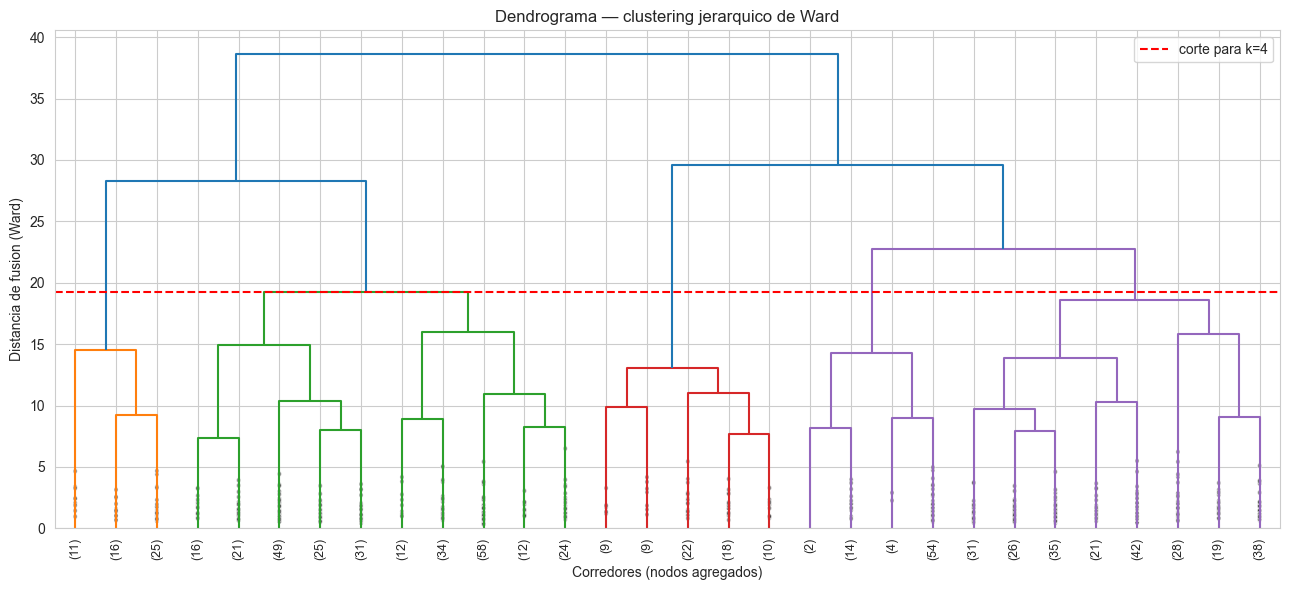

In [46]:
# BLOQUE 16 - Creacion dendrograma (Ward) y sugerencia de corte

plt.figure(figsize=(13, 6))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90,
           leaf_font_size=9, show_contracted=True)
plt.axhline(y=Z[-5, 2], color="red", ls="--", label="corte para k=4")
plt.title("Dendrograma — clustering jerarquico de Ward")
plt.xlabel("Corredores (nodos agregados)")
plt.ylabel("Distancia de fusion (Ward)")
plt.legend(); plt.tight_layout()
plt.savefig("fig_ward_dendrograma.png", dpi=150, bbox_inches="tight")
plt.show()

In [47]:
# BLOQUE 17 - Modelo jerarquico (Ward) con corte en k=5

K = 5
etq_ward = fcluster(Z, t=K, criterion="maxclust")
perfiles["cluster_ward"] = etq_ward

print(f"Ward (k={K}) ajustado")
print(f"  Etiquetas en perfiles['cluster_ward']")
print(f"  Clusteres: {sorted(set(etq_ward))}")

Ward (k=5) ajustado
  Etiquetas en perfiles['cluster_ward']
  Clusteres: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5)]


In [48]:
# BLOQUE 18 - Analisis de los clusters Ward

# ── Silueta ─────────────────────────────────────────────────────────────────
sil_ward = silhouette_score(Xp, etq_ward)
print(f"── Calidad del corte ──")
print(f"  Silueta (Ward, k=5): {sil_ward:.3f}")

# ── Tamanos ─────────────────────────────────────────────────────────────────
tam = pd.Series(etq_ward).value_counts().sort_index()
print("\n── Tamanos (Ward) ──")
for c, n in tam.items():
    print(f"  Cluster {c}: {n:>3} corredores ({n/len(perfiles)*100:.1f}%)")

# ── Concordancia con K-Means: ARI ──────────────────────────────────────────
#    ARI = 1 → particiones identicas; ~0 → coincidencia azarosa.
#    Es el indicador clave de la triangulacion entre ambos metodos.
ari = adjusted_rand_score(perfiles["cluster"], etq_ward)
print(f"\n── Concordancia K-Means vs Ward ──")
print(f"  ARI = {ari:.3f}")

# ── Tabla de contingencia: como se solapan los grupos de ambos metodos ─────
print("\n── Contingencia (filas = K-Means, columnas = Ward) ──")
print(pd.crosstab(perfiles["cluster"], perfiles["cluster_ward"],
                  rownames=["KMeans"], colnames=["Ward"]).to_string())

# ── Perfil mediano de cada cluster Ward (para comparar con K-Means) ────────
print("\n── Perfil mediano por cluster Ward (unidades originales) ──")
print(perfiles.groupby("cluster_ward")[FEATURES].median().round(2).to_string())

── Calidad del corte ──
  Silueta (Ward, k=5): 0.125

── Tamanos (Ward) ──
  Cluster 1:  52 corredores (7.3%)
  Cluster 2: 282 corredores (39.4%)
  Cluster 3:  68 corredores (9.5%)
  Cluster 4:  74 corredores (10.3%)
  Cluster 5: 240 corredores (33.5%)

── Concordancia K-Means vs Ward ──
  ARI = 0.431

── Contingencia (filas = K-Means, columnas = Ward) ──
Ward     1    2   3   4    5
KMeans                      
0       51   41   2   0   39
1        0   30   8  67   29
2        1  189   2   2   12
3        0   15   2   4  158
4        0    7  54   1    2

── Perfil mediano por cluster Ward (unidades originales) ──
              dist_median  dist_std  speed_median  speed_std  hr_mean_median  hr_max_median  hr_std_median  elev_gain_median
cluster_ward                                                                                                                
1                    6.20      1.68          8.20       0.70          143.58         163.25          13.18             66.45
2  

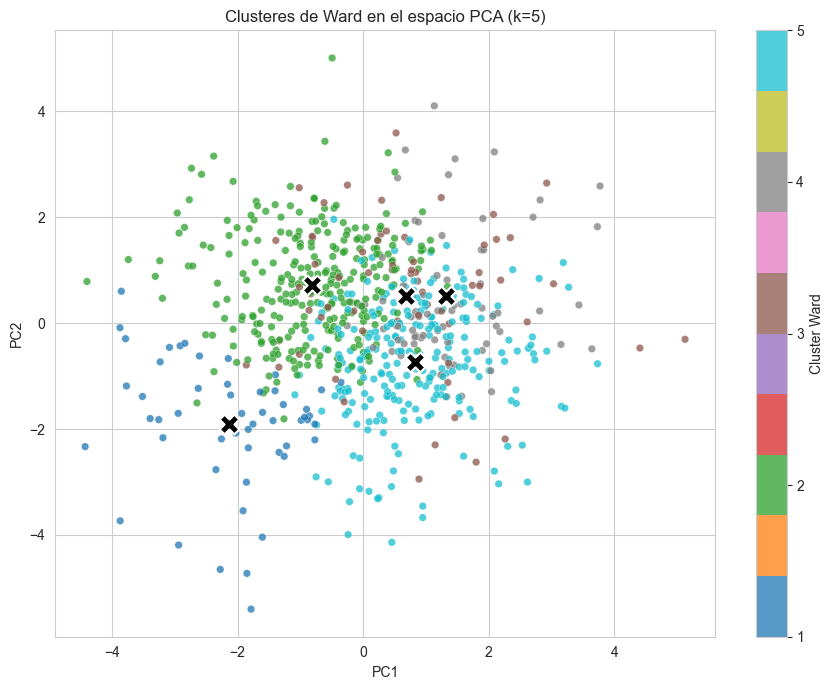

✅ fig_ward_pca.png guardado


In [49]:
# BLOQUE 19 - Visualizacion de los clusters Ward

K = 5
fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(Xp[:, 0], Xp[:, 1], c=etq_ward, cmap="tab10",
                s=30, alpha=0.75, edgecolor="white", linewidth=0.3)
for c in np.unique(etq_ward):
    cx, cy = Xp[etq_ward == c, 0].mean(), Xp[etq_ward == c, 1].mean()
    ax.scatter(cx, cy, c="black", marker="X", s=200,
               edgecolor="white", linewidth=1.5, zorder=5)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title(f"Clusteres de Ward en el espacio PCA (k={K})")
plt.colorbar(sc, ax=ax, label="Cluster Ward", ticks=range(1, K + 1))
plt.tight_layout()
plt.savefig("fig_ward_pca.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ fig_ward_pca.png guardado")

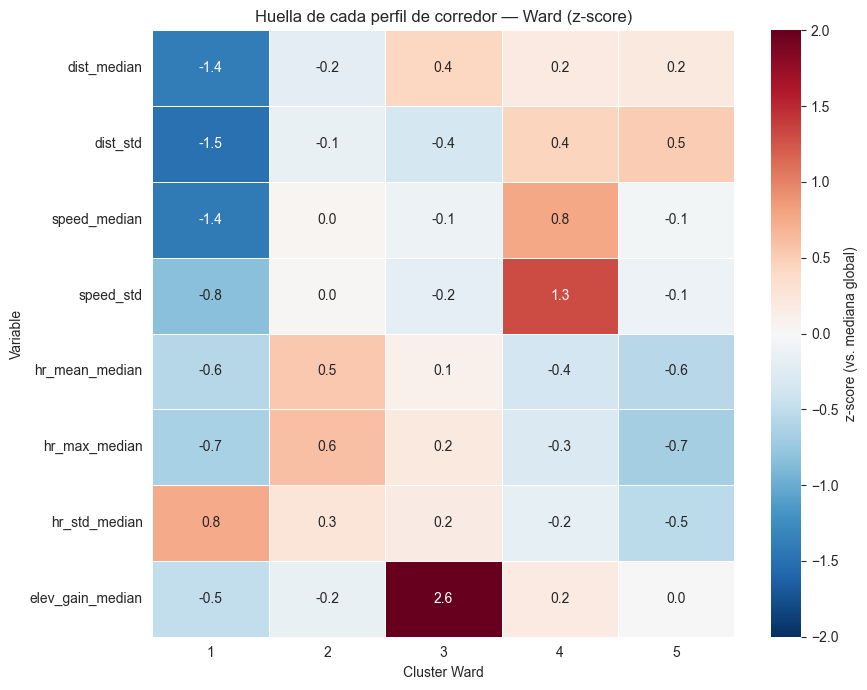

✅ fig_ward_heatmap.png guardado


In [50]:
# BLOQUE 20 - Heatmap de los clusters Ward

resumen_w = perfiles.groupby("cluster_ward")[FEATURES].median()
zsc_w = ((resumen_w - perfiles[FEATURES].median()) / perfiles[FEATURES].std())

plt.figure(figsize=(9, 7))
sns.heatmap(zsc_w.T, cmap="RdBu_r", center=0, vmin=-2, vmax=2,
            annot=True, fmt=".1f", linewidths=0.5,
            cbar_kws={"label": "z-score (vs. mediana global)"})
plt.xlabel("Cluster Ward"); plt.ylabel("Variable")
plt.title("Huella de cada perfil de corredor — Ward (z-score)")
plt.tight_layout()
plt.savefig("fig_ward_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ fig_ward_heatmap.png guardado")

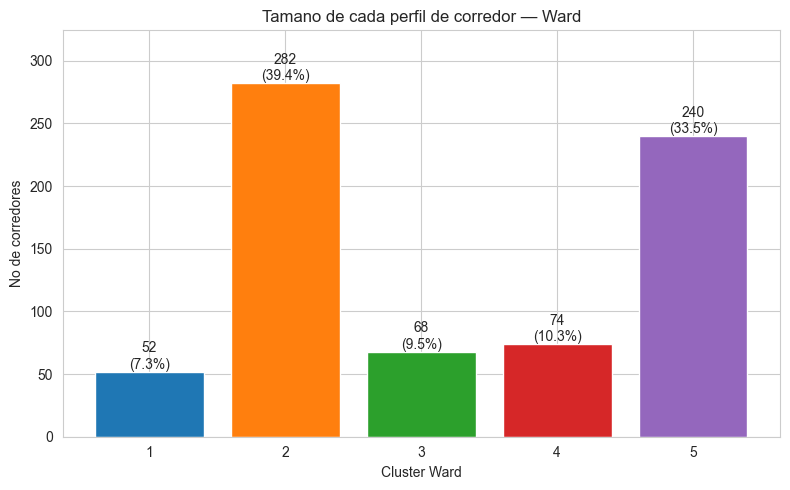

✅ fig_ward_tamanos.png guardado


In [51]:
# BLOQUE 21 - Distribucion de los usuarios por cluster Ward

tam = perfiles["cluster_ward"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.bar(tam.index.astype(str), tam.values,
                color=plt.cm.tab10(range(len(tam))), edgecolor="white")
for b, n in zip(barras, tam.values):
    ax.text(b.get_x() + b.get_width()/2, b.get_height(),
            f"{n}\n({n/tam.sum()*100:.1f}%)",
            ha="center", va="bottom", fontsize=10)
ax.set_xlabel("Cluster Ward"); ax.set_ylabel("No de corredores")
ax.set_title("Tamano de cada perfil de corredor — Ward")
ax.margins(y=0.15)
plt.tight_layout()
plt.savefig("fig_ward_tamanos.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ fig_ward_tamanos.png guardado")

In [52]:
# Recojo las etiquetas de cada modelo
modelos = {
    "K-Means": perfiles["cluster"].values,
    "Ward":    perfiles["cluster_ward"].values,
    "DBSCAN":  perfiles["cluster_dbscan"].values,
}

filas = []
for nombre, etq in modelos.items():
    # no de clusteres reales (DBSCAN puede marcar ruido con -1)
    n_clusters = len(set(etq)) - (1 if -1 in etq else 0)

    # Si solo hay 1 cluster, las metricas no se pueden calcular
    if n_clusters < 2:
        filas.append({"Modelo": nombre, "n_clusters": n_clusters,
                      "Silueta": None, "Davies-Bouldin": None,
                      "Calinski-Harabasz": None})
        continue

    # En DBSCAN excluyo el ruido para medir solo los puntos agrupados
    mask = etq != -1
    filas.append({
        "Modelo": nombre,
        "n_clusters": n_clusters,
        "Silueta": round(silhouette_score(Xp[mask], etq[mask]), 3),
        "Davies-Bouldin": round(davies_bouldin_score(Xp[mask], etq[mask]), 3),
        "Calinski-Harabasz": round(calinski_harabasz_score(Xp[mask], etq[mask]), 1),
    })

comparativa = pd.DataFrame(filas)
print(comparativa.to_string(index=False))

 Modelo  n_clusters  Silueta  Davies-Bouldin  Calinski-Harabasz
K-Means           5     0.15            1.62             116.30
   Ward           5     0.12            1.72              92.00
 DBSCAN           1      NaN             NaN                NaN


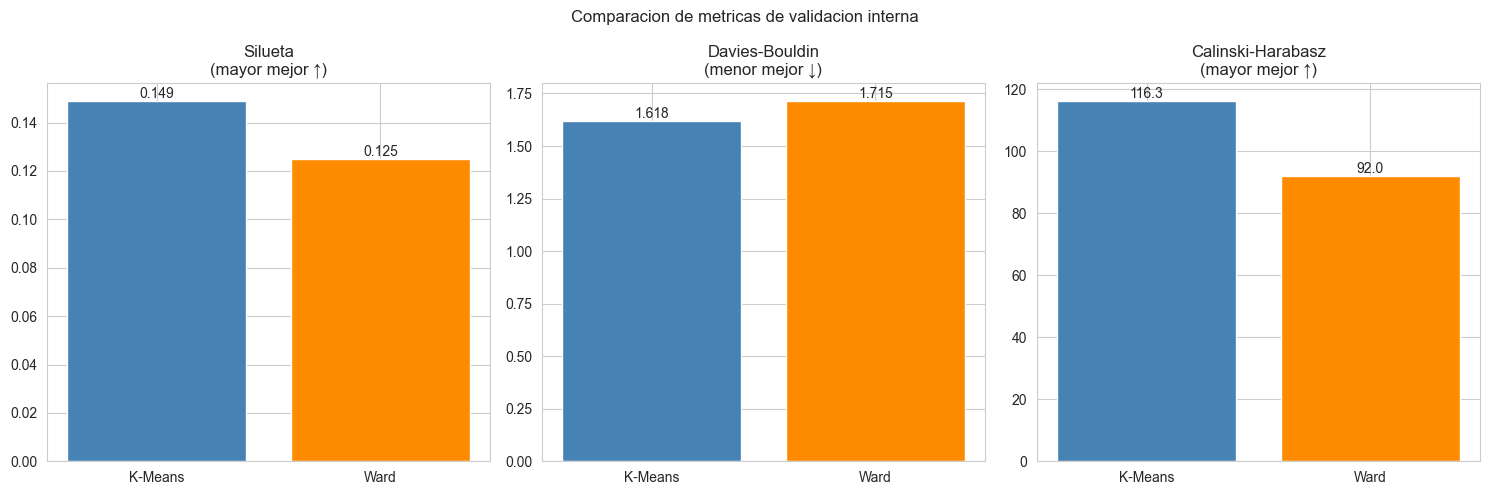

In [53]:
# Me quedo solo con los modelos que tienen metricas (DBSCAN dio 1 cluster → queda fuera)
datos = comparativa.dropna(subset=["Silueta"])

metricas = [
    ("Silueta", "mayor mejor ↑"),
    ("Davies-Bouldin", "menor mejor ↓"),
    ("Calinski-Harabasz", "mayor mejor ↑"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (col, nota) in zip(axes, metricas):
    ax.bar(datos["Modelo"], datos[col], color=["steelblue", "darkorange"])
    ax.set_title(f"{col}\n({nota})")
    # etiqueta con el valor encima de cada barra
    for i, v in enumerate(datos[col]):
        ax.text(i, v, f"{v}", ha="center", va="bottom")

plt.suptitle("Comparacion de metricas de validacion interna")
plt.tight_layout()
plt.savefig("fig_comparativa_metricas.png", dpi=150, bbox_inches="tight")
plt.show()

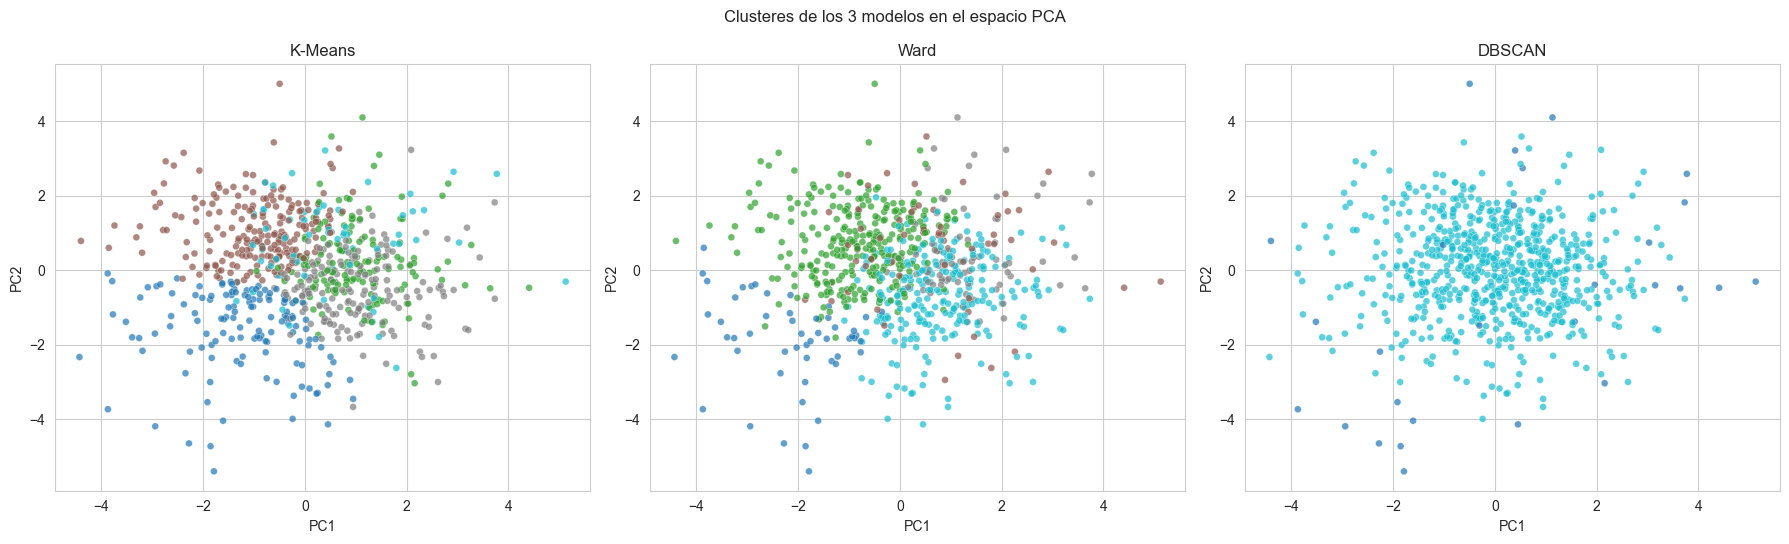

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

modelos = [
    ("K-Means", perfiles["cluster"]),
    ("Ward",    perfiles["cluster_ward"]),
    ("DBSCAN",  perfiles["cluster_dbscan"]),
]

for ax, (nombre, etq) in zip(axes, modelos):
    sc = ax.scatter(Xp[:, 0], Xp[:, 1], c=etq, cmap="tab10",
                    s=25, alpha=0.7, edgecolor="white", linewidth=0.3)
    ax.set_title(nombre)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")

plt.suptitle("Clusteres de los 3 modelos en el espacio PCA")
plt.tight_layout()
plt.savefig("fig_scatter_3modelos.png", dpi=150, bbox_inches="tight")
plt.show()

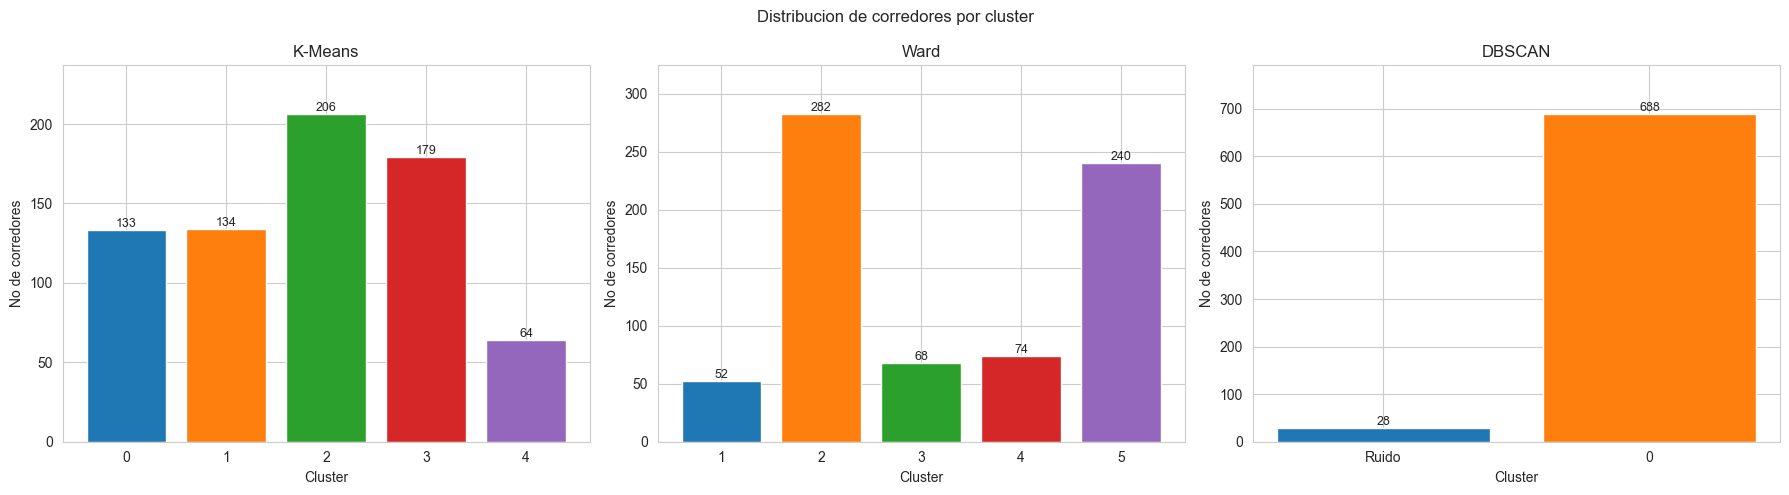

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (nombre, etq) in zip(axes, modelos):
    conteo = etq.value_counts().sort_index()   # incluye el -1 (ruido) en DBSCAN
    etiquetas = ["Ruido" if c == -1 else str(c) for c in conteo.index]
    barras = ax.bar(etiquetas, conteo.values,
                    color=plt.cm.tab10(range(len(conteo))), edgecolor="white")
    for b, n in zip(barras, conteo.values):
        ax.text(b.get_x() + b.get_width()/2, b.get_height(),
                f"{n}", ha="center", va="bottom", fontsize=9)
    ax.set_title(nombre)
    ax.set_xlabel("Cluster"); ax.set_ylabel("No de corredores")
    ax.margins(y=0.15)

plt.suptitle("Distribucion de corredores por cluster")
plt.tight_layout()
plt.savefig("fig_distribucion_3modelos.png", dpi=150, bbox_inches="tight")
plt.show()

In [56]:
filas = []
for nombre, etq in modelos:
    conteo = etq.value_counts()
    n_ruido = conteo.get(-1, 0)
    grupos = conteo.drop(-1, errors="ignore")   # tamanos sin contar el ruido
    filas.append({
        "Modelo": nombre,
        "No clusteres": len(grupos),
        "Grupo mayor": grupos.max(),
        "Grupo menor": grupos.min(),
        "Ruido": n_ruido,
    })

print(pd.DataFrame(filas).to_string(index=False))

 Modelo  No clusteres  Grupo mayor  Grupo menor  Ruido
K-Means             5          206           64      0
   Ward             5          282           52      0
 DBSCAN             1          688          688     28


In [ ]:
# Nombres de los perfiles Kmeans
nombres = {
    0: "Recreativo de bajo volumen",
    1: "Veloz de ritmo variable",
    2: "Alta intensidad cardiaca",
    3: "Fondo a baja intensidad",
    4: "Montana / desnivel",
}
perfiles["perfil"] = perfiles["cluster"].map(nombres)

# Tabla resumen: nombre, nº de corredores y medianas clave por perfil
resumen = perfiles.groupby("cluster").agg(
    n        = ("user_id", "size"),
    dist     = ("dist_median", "median"),
    speed    = ("speed_median", "median"),
    hr_mean  = ("hr_mean_median", "median"),
    hr_max   = ("hr_max_median", "median"),
    elev     = ("elev_gain_median", "median"),
).round(1)
resumen.insert(0, "perfil", [nombres[c] for c in resumen.index])
print(resumen.to_string())

# Guardo los perfiles ya etiquetados (resultado final del estudio)
perfiles.to_csv("data/run_profiles_clustered.csv", index=False)
print("\nGuardado: data/run_profiles_clustered.csv")

                             perfil    n  dist  speed  hr_mean  hr_max   elev
cluster                                                                      
0        Recreativo de bajo volumen  133  7.30   9.10   144.10  165.00  76.90
1           Veloz de ritmo variable  134 10.10  11.40   145.10  167.00 123.20
2          Alta intensidad cardiaca  206  9.90  10.60   158.70  178.50  97.00
3           Fondo a baja intensidad  179 11.20  10.70   146.20  164.00 105.30
4                Montana / desnivel   64 11.40  10.60   151.50  173.00 330.20

Guardado: data/run_profiles_clustered.csv


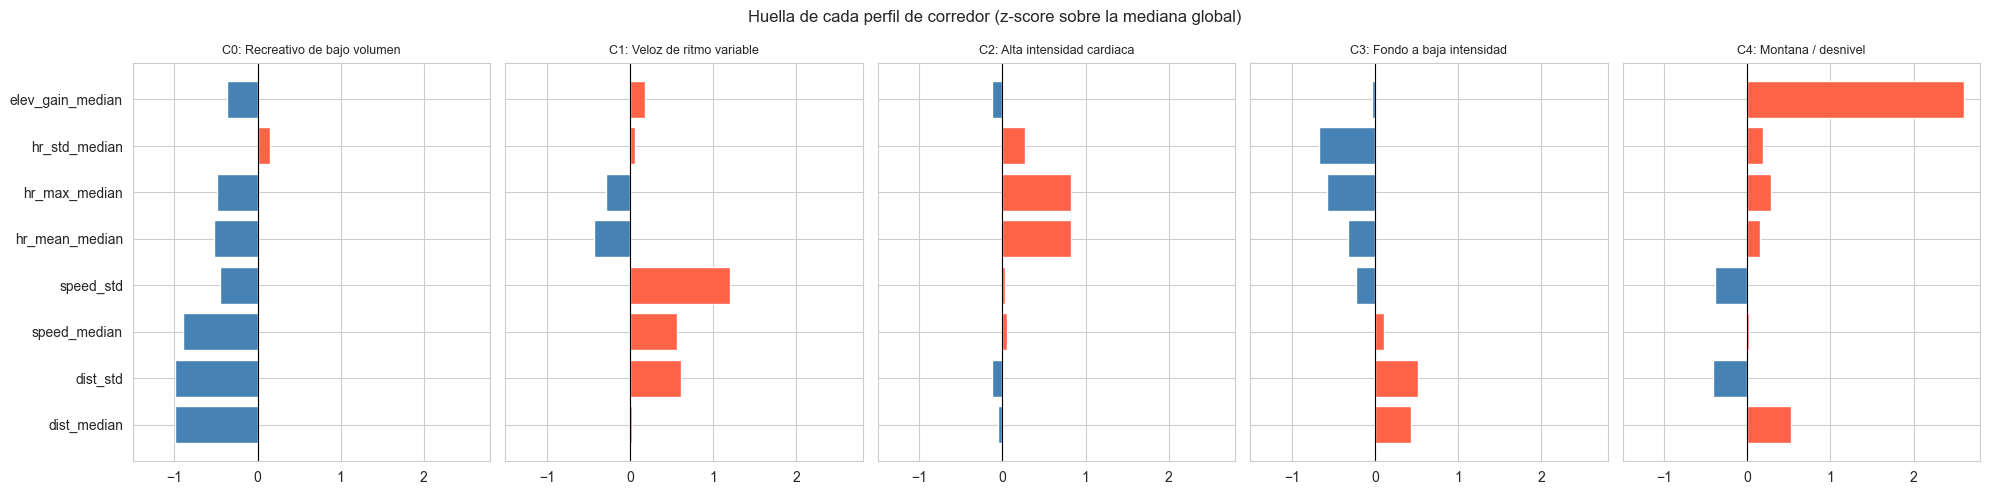

In [58]:
import matplotlib.pyplot as plt

zsc = perfiles.groupby("cluster")[FEATURES].median()
zsc = (zsc - perfiles[FEATURES].median()) / perfiles[FEATURES].std()

fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharey=True)
for ax, c in zip(axes, zsc.index):
    colores = ["tomato" if v > 0 else "steelblue" for v in zsc.loc[c]]
    ax.barh(FEATURES, zsc.loc[c], color=colores)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"C{c}: {nombres[c]}", fontsize=9)
    ax.set_xlim(-1.5, 2.8)

fig.suptitle("Huella de cada perfil de corredor (z-score sobre la mediana global)")
plt.tight_layout()
plt.savefig("fig_perfiles_huella.png", dpi=150, bbox_inches="tight")
plt.show()